In [1]:
import os
import json
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

# 1. EDA

## 1.1 Data importing and overview

In [2]:
meta_dir = '/kaggle/input/datasets/dong10082005/sashts/sashts_metadata.csv'
net_dir = '/kaggle/input/datasets/dong10082005/sashts/sashts_contact_network.csv'

df_meta = pd.read_csv(meta_dir)
df_net = pd.read_csv(net_dir)

In [3]:
df_meta

,indid,site,agegrp9,sex,ind_inc_ana,hhid,smokecignow1,bmicat,ixagegrp9,ixsex,ixminctcat1,ixminctcat2,sleep_room_ix,cared_by_ix,sus,ixesarsvarf1,index,sars
0,J008-001,Klerksdorp,18-34,Female,Yes,J008,No,Obese,NaN,NaN,NaN,NaN,Unknown,No,NaN,NaN,Index,Positive
1,J008-002,Klerksdorp,35-59,Male,Yes,J008,Yes,Overweight,18-34,Female,25-35,<30,No,No,Susceptible,non-Alpha/Beta/Delta,Contact,Negative
2,J008-004,Klerksdorp,<5,Male,Yes,J008,No,Normal weight,18-34,Female,25-35,<30,Yes,Yes,Susceptible,non-Alpha/Beta/Delta,Contact,Positive
3,J008-005,Klerksdorp,12-May,Female,Yes,J008,No,Normal weight,18-34,Female,25-35,<30,Yes,No,Susceptible,non-Alpha/Beta/Delta,Contact,Positive
4,J008-006,Klerksdorp,13-17,Female,Yes,J008,No,Normal weight,18-34,Female,25-35,<30,Yes,No,Susceptible,non-Alpha/Beta/Delta,Contact,Positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
335,S080-001,Soweto,18-34,Male,Yes,S080,Yes,Normal weight,NaN,NaN,NaN,NaN,Unknown,No,NaN,NaN,Index,Positive
336,S080-002,Soweto,35-59,Male,Yes,S080,Yes,Normal weight,18-34,Male,>35,>35,No,No,Susceptible,Variant Unknown,Contact,Negative
337,S080-003,Soweto,35-59,Female,Yes,S080,No,Obese,18-34,Male,>35,>35,No,No,Susceptible,Variant Unknown,Contact,Negative
338,S081-001,Soweto,35-59,Female,Yes,S081,No,Obese,NaN,NaN,NaN,NaN,Unknown,No,NaN,NaN,Index,Positive


In [4]:
df_meta.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340 entries, 0 to 339
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   indid          340 non-null    object
 1   site           340 non-null    object
 2   agegrp9        340 non-null    object
 3   sex            340 non-null    object
 4   ind_inc_ana    340 non-null    object
 5   hhid           340 non-null    object
 6   smokecignow1   340 non-null    object
 7   bmicat         340 non-null    object
 8   ixagegrp9      252 non-null    object
 9   ixsex          252 non-null    object
 10  ixminctcat1    252 non-null    object
 11  ixminctcat2    252 non-null    object
 12  sleep_room_ix  340 non-null    object
 13  cared_by_ix    340 non-null    object
 14  sus            252 non-null    object
 15  ixesarsvarf1   252 non-null    object
 16  index          340 non-null    object
 17  sars           340 non-null    object
dtypes: object(18)
memory usage: 47

In [5]:
df_net

,t,duration_sec,indid1,indid2,date,pair,hh,deployed1,collected1,deployed2,...,no_ts,sars_indid1,age_indid1,sars_indid2,age_indid2,contacts,contacts_infected,hcir,hh_ar,pair_sars
0,1/2/1970 0:18,40,J027-002,J027-001,1/2/1970,J027-002_J027-001,J027,1/25/2021,2/9/2021,1/25/2021,...,1,Negative,35-59,Positive,35-59,4,2,50,60,No transmission
1,1/2/1970 0:22,100,J027-002,J027-001,1/2/1970,J027-002_J027-001,J027,1/25/2021,2/9/2021,1/25/2021,...,1,Negative,35-59,Positive,35-59,4,2,50,60,No transmission
2,1/2/1970 0:24,20,J027-002,J027-001,1/2/1970,J027-002_J027-001,J027,1/25/2021,2/9/2021,1/25/2021,...,1,Negative,35-59,Positive,35-59,4,2,50,60,No transmission
3,1/2/1970 5:00,40,J027-002,J027-001,1/2/1970,J027-002_J027-001,J027,1/25/2021,2/9/2021,1/25/2021,...,1,Negative,35-59,Positive,35-59,4,2,50,60,No transmission
4,1/2/1970 5:42,20,J027-002,J027-001,1/2/1970,J027-002_J027-001,J027,1/25/2021,2/9/2021,1/25/2021,...,1,Negative,35-59,Positive,35-59,4,2,50,60,No transmission
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140537,5/19/2021 16:47,40,S049-005,S049-001,5/19/2021,S049-005_S049-001,S049,5/8/2021,5/22/2021,5/8/2021,...,0,Negative,60,Positive,35-59,4,1,25,40,No transmission
140538,5/19/2021 16:48,20,S049-005,S049-001,5/19/2021,S049-005_S049-001,S049,5/8/2021,5/22/2021,5/8/2021,...,0,Negative,60,Positive,35-59,4,1,25,40,No transmission
140539,5/19/2021 20:20,20,S049-005,S049-001,5/19/2021,S049-005_S049-001,S049,5/8/2021,5/22/2021,5/8/2021,...,0,Negative,60,Positive,35-59,4,1,25,40,No transmission
140540,5/20/2021 18:23,20,S049-005,S049-001,5/20/2021,S049-005_S049-001,S049,5/8/2021,5/22/2021,5/8/2021,...,0,Negative,60,Positive,35-59,4,1,25,40,No transmission


In [6]:
df_net.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140542 entries, 0 to 140541
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   t                  140542 non-null  object
 1   duration_sec       140542 non-null  int64 
 2   indid1             140542 non-null  object
 3   indid2             140542 non-null  object
 4   date               140542 non-null  object
 5   pair               140542 non-null  object
 6   hh                 140542 non-null  object
 7   deployed1          140542 non-null  object
 8   collected1         140542 non-null  object
 9   deployed2          140542 non-null  object
 10  collected2         140542 non-null  object
 11  no_ts              140542 non-null  int64 
 12  sars_indid1        140542 non-null  object
 13  age_indid1         140542 non-null  object
 14  sars_indid2        140542 non-null  object
 15  age_indid2         140542 non-null  object
 16  contacts           1

## 1.2 Descriptive statistics

In [7]:
# Numeric statistics for contact network
net_num_col = ['duration_sec', 'no_ts', 'contacts', 'contacts_infected', 'hcir', 'hh_ar']

print('=== Numeric statistics: df_net ===')
display(df_net[net_num_col].describe().T)

print('=== Metadata overview: df_meta ===')
display(df_meta.describe(include='all').T)

cat_cols = ['agegrp9', 'sex', 'site', 'index', 'sars']
for col in cat_cols:
    print(f'\n[{col}] value_counts:')
    display(df_meta[col].value_counts(dropna=False).to_frame('count'))

=== Numeric statistics: df_net ===


,count,mean,std,min,25%,50%,75%,max
duration_sec,140542.0,57.044585,144.183594,20.0,20.0,20.0,60.0,14960.0
no_ts,140542.0,0.320545,0.466688,0.0,0.0,0.0,1.0,1.0
contacts,140542.0,4.238975,1.681162,1.0,3.0,4.0,5.0,8.0
contacts_infected,140542.0,2.280101,1.711097,0.0,1.0,2.0,3.0,7.0
hcir,140542.0,52.298786,34.324333,0.0,20.0,57.0,83.0,100.0
hh_ar,140542.0,62.883736,26.171867,14.0,33.0,67.0,86.0,100.0


=== Metadata overview: df_meta ===


,count,unique,top,freq
indid,340,340,S081-003,1
site,340,2,Soweto,197
agegrp9,340,6,35-59,116
sex,340,2,Female,205
ind_inc_ana,340,1,Yes,340
hhid,340,88,S007,8
smokecignow1,340,3,No,294
bmicat,340,5,Normal weight,140
ixagegrp9,252,3,35-59,137
ixsex,252,2,Female,176



[agegrp9] value_counts:


...

,count
site,
Soweto,197
Klerksdorp,143



[index] value_counts:


,count
index,
Contact,252
Index,88



[sars] value_counts:


,count
sars,
Positive,241
Negative,99


In [8]:
# Save key tabular/text EDA outputs as PNG files for reporting
from io import StringIO

def save_text_as_png(text, filename, figsize=(12, 6), fontsize=9):
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis('off')
    ax.text(0.01, 0.99, text, va='top', ha='left', family='monospace', fontsize=fontsize)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.close(fig)

def save_dataframe_as_png(dataframe, filename, figsize=(12, 4), fontsize=8):
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis('off')
    table = ax.table(
        cellText=dataframe.round(3).astype(str).values,
        colLabels=dataframe.columns,
        rowLabels=dataframe.index,
        loc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(1, 1.2)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.close(fig)

meta_info_buffer = StringIO()
df_meta.info(buf=meta_info_buffer)
save_text_as_png(meta_info_buffer.getvalue(), 'eda_df_meta_info.png')

net_info_buffer = StringIO()
df_net.info(buf=net_info_buffer)
save_text_as_png(net_info_buffer.getvalue(), 'eda_df_net_info.png')

save_dataframe_as_png(df_net[net_num_col].describe().T, 'eda_df_net_describe.png')

## 1.3 Univariate EDA

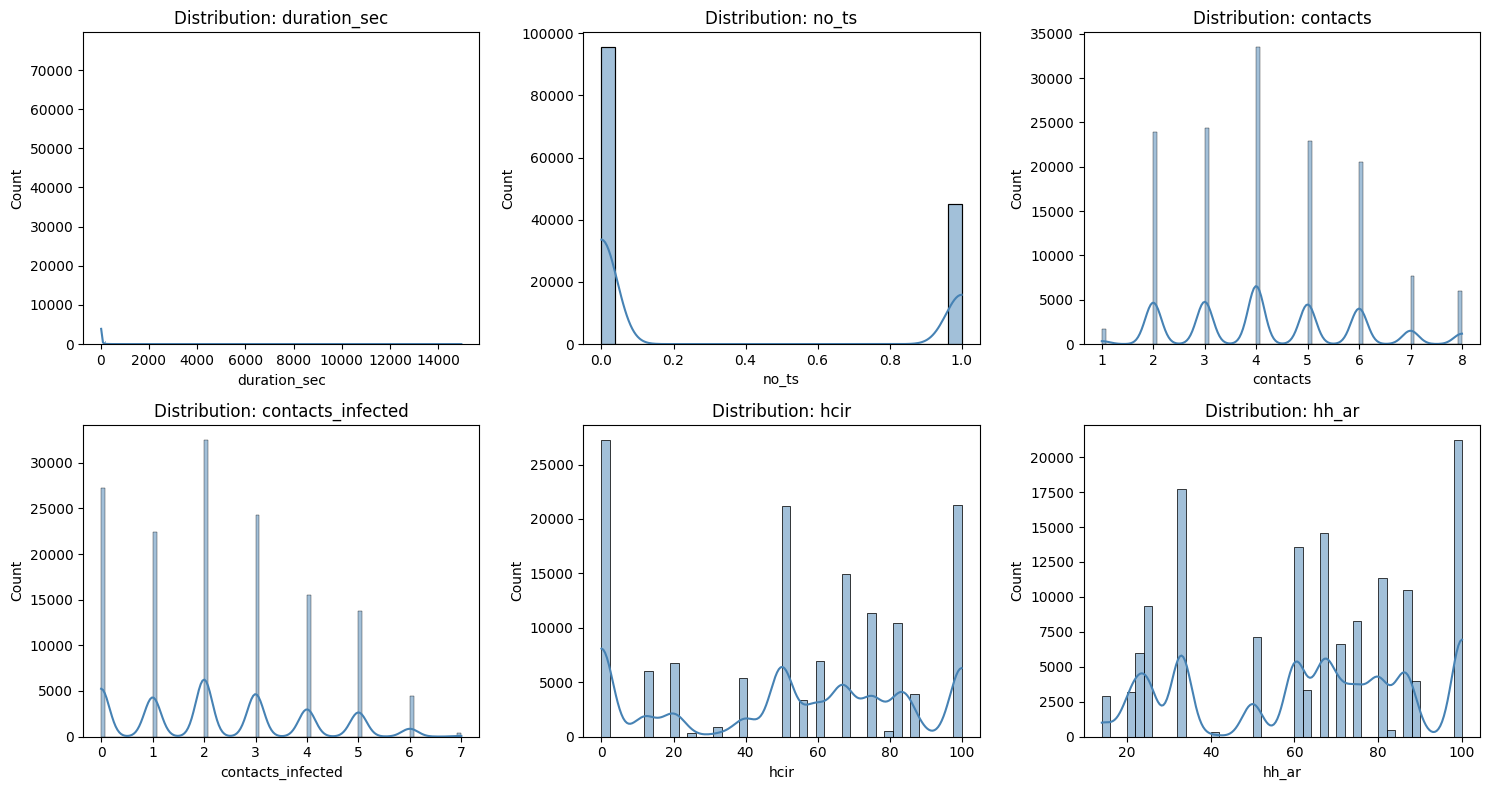

In [9]:
# Distribution of numeric variables in contact network
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), net_num_col):
    sns.histplot(df_net[col].dropna(), kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution: {col}')
plt.tight_layout()
plt.savefig('eda_univariate.png', dpi=150, bbox_inches='tight')
plt.show()

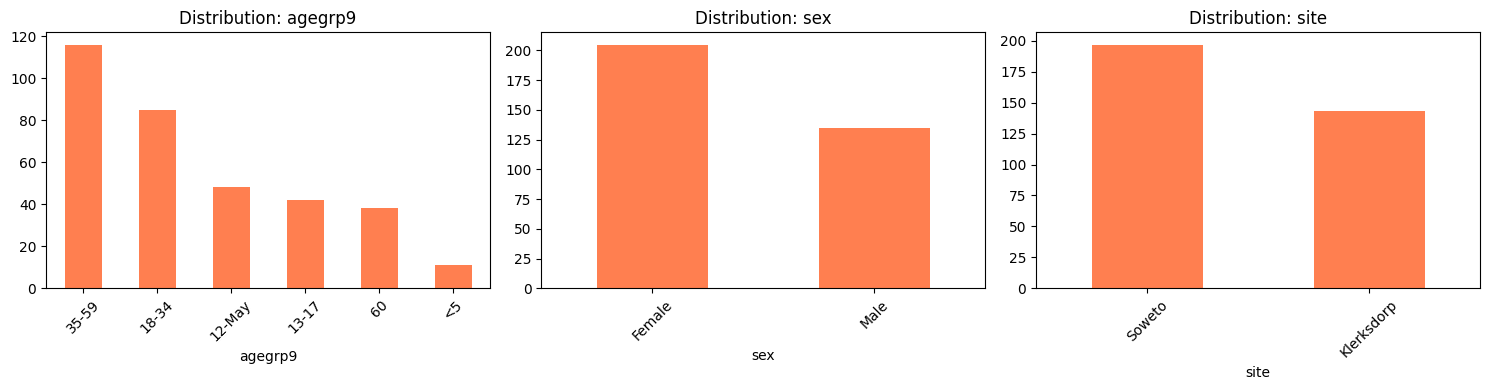

In [10]:
# Distribution of key categorical variables in metadata
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['agegrp9', 'sex', 'site']):
    df_meta[col].value_counts(dropna=False).plot(kind='bar', ax=ax, color='coral')
    ax.set_title(f'Distribution: {col}')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('eda_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.4 Correlation analysis

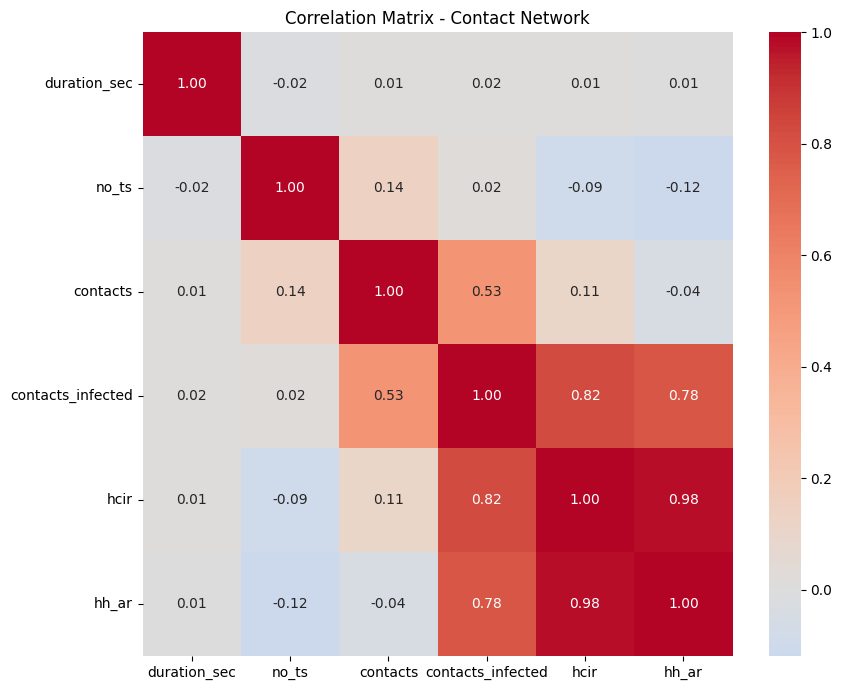

In [11]:
# Correlation matrix for numeric contact-network variables
corr = df_net[net_num_col].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix - Contact Network')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.5 EDA insights

- The metadata table is mostly categorical, so frequency tables are more informative than numeric summaries for demographic and infection-status fields.
- The contact-network table contains the main numeric measures: duration, time-slot count, household contacts, infected contacts, household cumulative infection risk, and household attack rate.
- Histograms and boxplots should be used together because contact duration and contact counts can be strongly skewed.
- The correlation heatmap helps identify redundant or related measures before OLAP/star-cubing preparation, especially relationships among contacts, infected contacts, hcir, and hh_ar.

# 2. ETL

## 2.1 Missing value preprocessing

In [12]:
is_f0 = df_meta[df_meta['index'] == 'Index']
print(f'Số lượng F0: {len(is_f0)} ca')

Số lượng F0: 88 ca


In [13]:
with pd.option_context('display.max_rows', None):
    display(is_f0)

,indid,site,agegrp9,sex,ind_inc_ana,hhid,smokecignow1,bmicat,ixagegrp9,ixsex,ixminctcat1,ixminctcat2,sleep_room_ix,cared_by_ix,sus,ixesarsvarf1,index,sars
0,J008-001,Klerksdorp,18-34,Female,Yes,J008,No,Obese,NaN,NaN,NaN,NaN,Unknown,No,NaN,NaN,Index,Positive
6,J009-001,Klerksdorp,35-59,Female,Yes,J009,No,Obese,NaN,NaN,NaN,NaN,Unknown,No,NaN,NaN,Index,Positive
8,J010-001,Klerksdorp,18-34,Male,Yes,J010,Yes,Normal weight,NaN,NaN,NaN,NaN,Unknown,No,NaN,NaN,Index,Positive
11,J020-001,Klerksdorp,18-34,Male,Yes,J020,No,Normal weight,NaN,NaN,NaN,NaN,Unknown,No,NaN,NaN,Index,Positive
16,J021-001,Klerksdorp,35-59,Female,Yes,J021,Unknown,Unknown,NaN,NaN,NaN,NaN,Unknown,No,NaN,NaN,Index,Positive
19,J022-001,Klerksdorp,35-59,Male,Yes,J022,No,Overweight,NaN,NaN,NaN,NaN,Unknown,No,NaN,NaN,Index,Positive
22,J023-001,Klerksdorp,18-34,Male,Yes,J023,No,Obese,NaN,NaN,NaN,NaN,Unknown,No,NaN,NaN,Index,Positive
28,J024-001,Klerksdorp,35-59,Female,Yes,J024,No,Obese,NaN,NaN,NaN,NaN,Unknown,No,NaN,NaN,Index,Positive
31,J027-001,Klerksdorp,35-59,Female,Yes,J027,No,Obese,NaN,NaN,NaN,NaN,Unknown,No,NaN,NaN,Index,Positive
36,J029-001,Klerksdorp,35-59,Female,Yes,J029,No,Normal weight,NaN,NaN,NaN,NaN,Unknown,No,NaN,NaN,Index,Positive


In [14]:
columns_to_fill = ['ixagegrp9', 'ixsex', 'ixminctcat1', 'ixminctcat2', 'sus', 'ixesarsvarf1']
df_meta[columns_to_fill] = df_meta[columns_to_fill].fillna('Self Index')

print('Kiểm tra NaN/Null:')
print(df_meta.isnull().sum())

Kiểm tra NaN/Null:
indid            0
site             0
agegrp9          0
sex              0
ind_inc_ana      0
hhid             0
smokecignow1     0
bmicat           0
ixagegrp9        0
ixsex            0
ixminctcat1      0
ixminctcat2      0
sleep_room_ix    0
cared_by_ix      0
sus              0
ixesarsvarf1     0
index            0
sars             0
dtype: int64


## 2.2 Fix CSV format problems

In [15]:
replace_dict = {'12-May': '5-12', '60': '>=60'}
df_meta['agegrp9'] = df_meta['agegrp9'].replace(replace_dict)

print('Kết quả sau sửa: ')
print(df_meta['agegrp9'].head(10))

Kết quả sau sửa: 
0    18-34
1    35-59
2       <5
3     5-12
4    13-17
5    18-34
6    35-59
7     >=60
8    18-34
9     >=60
Name: agegrp9, dtype: object


## 2.3 Consistency and range checks

In [16]:
meta_ids = set(df_meta['indid'].unique())

net_ids1 = set(df_net['indid1'].unique())
net_ids2 = set(df_net['indid2'].unique())
net_ids = net_ids1.union(net_ids2)

ids_in_net_not_in_meta = net_ids - meta_ids
ids_in_meta_not_in_net = meta_ids - net_ids

print(f"Tổng số ID trong Metadata: {len(meta_ids)}")
print(f"Tổng số ID trong Network : {len(net_ids)}")
print(f"Số ID có trong Network nhưng KHÔNG có trong Metadata: {len(ids_in_net_not_in_meta)}")
print(f"Số ID có trong Metadata nhưng KHÔNG có trong Network: {len(ids_in_meta_not_in_net)}")

Tổng số ID trong Metadata: 340
Tổng số ID trong Network : 340
Số ID có trong Network nhưng KHÔNG có trong Metadata: 0
Số ID có trong Metadata nhưng KHÔNG có trong Network: 0


In [17]:
is_out_range_hcir = df_net[(df_net['hcir']<0) | (df_net['hcir']>100)]
is_out_range_hh_ar = df_net[(df_net['hh_ar']<0) | (df_net['hh_ar']>100)]

total_out_range = len(is_out_range_hcir) + len(is_out_range_hh_ar)
print(f"Tổng số giá trị bị lỗi ngoài vùng: {total_out_range}")

Tổng số giá trị bị lỗi ngoài vùng: 0


## 2.4 Outlier detection and capping

In [18]:
meta_num = df_meta.select_dtypes(include=[np.number]).columns
print(f"Các cột dạng số trong metadata: {list(meta_num)}")

net_num = df_net.select_dtypes(include=[np.number]).columns
print(f"Các cột dạng số trong contact_network: {list(net_num)}")

Các cột dạng số trong metadata: []
Các cột dạng số trong contact_network: ['duration_sec', 'no_ts', 'contacts', 'contacts_infected', 'hcir', 'hh_ar']


In [19]:
# Các cột dạng số trong contact_network
net_num_col = ['duration_sec', 'no_ts', 'contacts', 'contacts_infected', 'hcir', 'hh_ar']

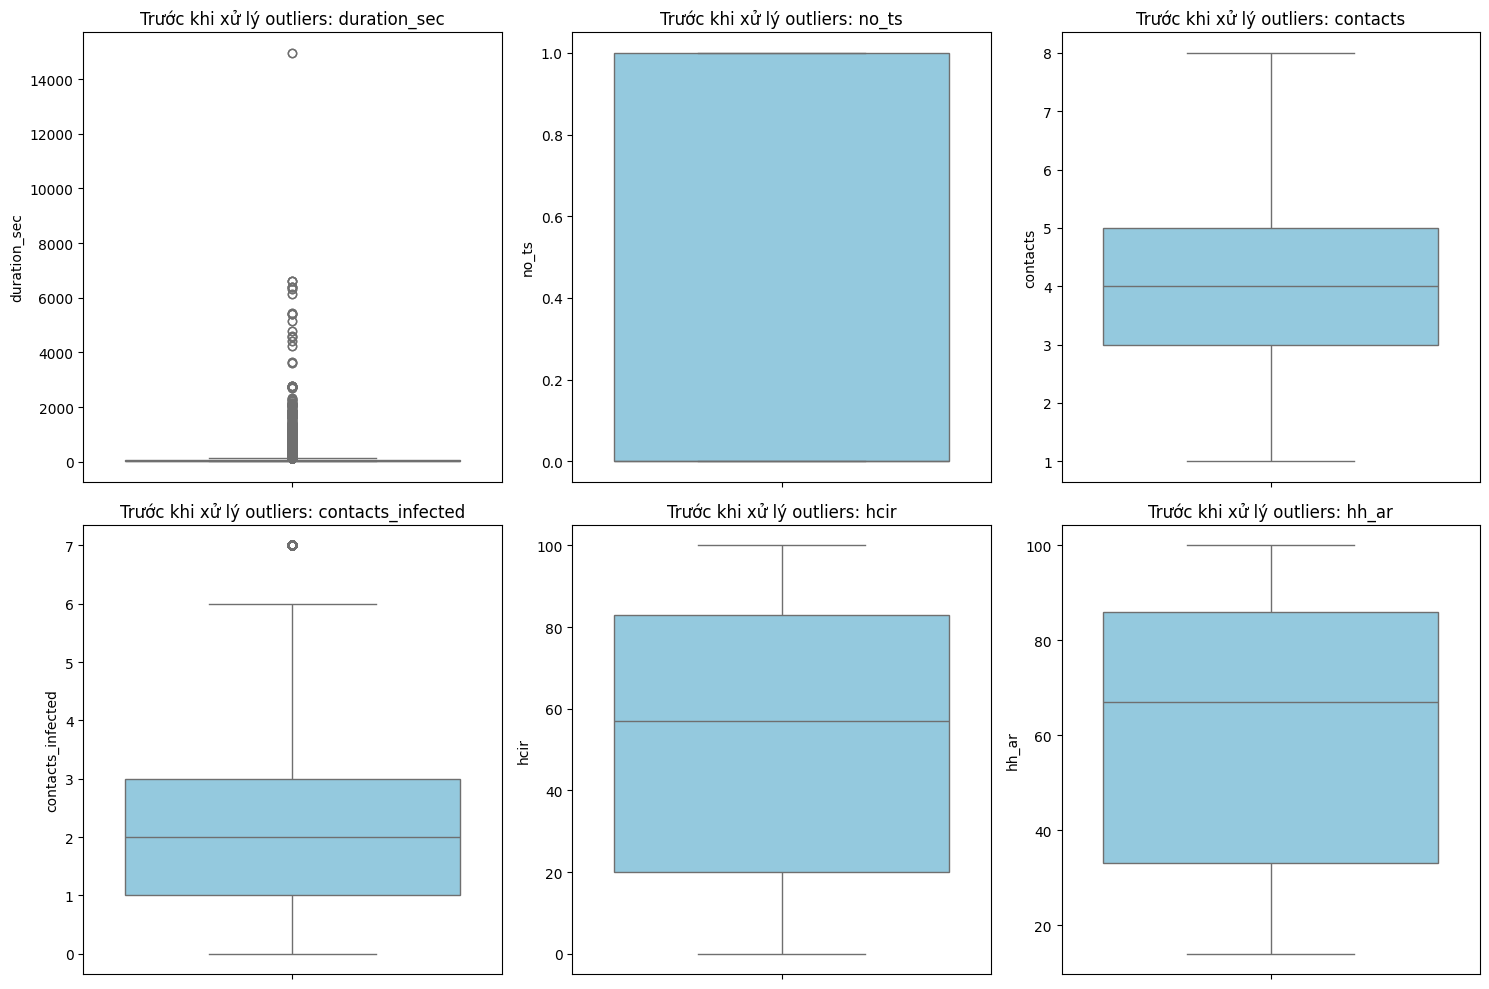

In [20]:
# Boxplot TRƯỚC KHI xử lý
plt.figure(figsize=(15, 10))
for i, col in enumerate(net_num_col, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df_net[col], color='skyblue')
    plt.title(f'Trước khi xử lý outliers: {col}')
plt.tight_layout()
plt.savefig('etl_boxplot_before.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Xử lý Outliers bằng phương pháp IQR
df_net_cleaned = df_net.copy()
outlier_summary = []

for col in net_num_col:
    Q1 = df_net[col].quantile(0.25)
    Q3 = df_net[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Đếm số lượng outliers
    outliers_count = ((df_net[col] < lower_bound) | (df_net[col] > upper_bound)).sum()
    outlier_summary.append({'Column': col, 'Outliers Count': outliers_count})
    
    # Capping
    df_net_cleaned[col] = np.clip(df_net_cleaned[col], lower_bound, upper_bound)

print("\nThống kê Outliers bị giới hạn:")
print(pd.DataFrame(outlier_summary))


Thống kê Outliers bị giới hạn:
              Column  Outliers Count
0       duration_sec           10370
1              no_ts               0
2           contacts               0
3  contacts_infected             380
4               hcir               0
5              hh_ar               0


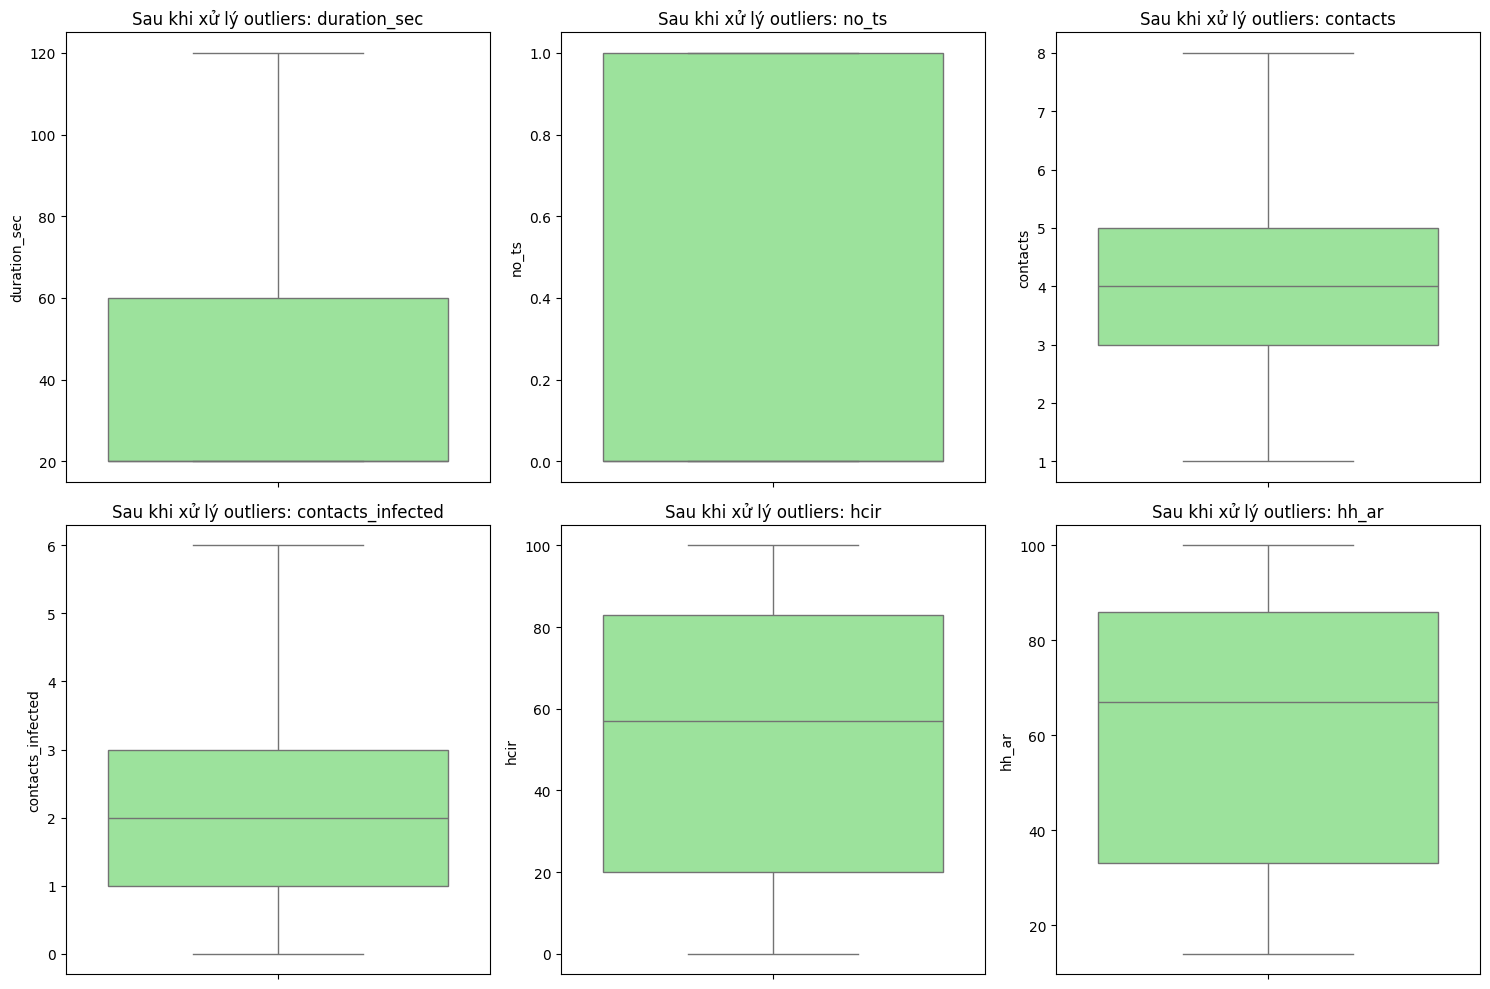

In [22]:
# Boxplot SAU KHI xử lý
plt.figure(figsize=(15, 10))
for i, col in enumerate(net_num_col, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df_net_cleaned[col], color='lightgreen')
    plt.title(f'Sau khi xử lý outliers: {col}')
plt.tight_layout()
plt.savefig('etl_boxplot_after.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.5 ETL preprocessing pipeline

```mermaid
graph TD
    A[Raw CSV: metadata + contact_network] --> B[Identify F0 records and fill categorical nulls as Self Index]
    B --> C[Fix agegrp9 format: 12-May to 5-12, 60 to >=60]
    C --> D[Cross-dataset consistency check: metadata IDs vs network IDs]
    D --> E[Range validation: hcir and hh_ar in 0-100]
    E --> F[Outlier detection with IQR]
    F --> G[Capping / winsorization]
    G --> H[Build star schema: dimensions + fact table]
    H --> I[Integer encoding for categorical columns]
    I --> J[Dimension ordering by cardinality]
    J --> K[df_result ready for Star Cubing]
```

## 2.6 Star schema transformation

### 2.6.1 Four dimensions and one fact table

In [23]:
# Dimension: Individual (dim_indid)
dim_indid = df_meta[['indid', 'site', 'agegrp9', 'sex', 'hhid', 'smokecignow1', 'bmicat', 'index', 'sars', 'sus', 'ixesarsvarf1']].drop_duplicates()
dim_indid = dim_indid.reset_index(drop=True)

In [24]:
# Dimension: Household (dim_household)
dim_household = df_net_cleaned[['hh', 'hcir', 'hh_ar', 'contacts', 'contacts_infected']].drop_duplicates()
dim_household = dim_household.rename(columns={'hh': 'hhid'}).reset_index(drop=True)

In [25]:
# Dimension: Date (dim_date)
df_net_cleaned['date_parsed'] = pd.to_datetime(df_net_cleaned['date'], errors='coerce')
dim_date = df_net_cleaned[['date', 'date_parsed']].drop_duplicates().reset_index(drop=True)
dim_date['date_id'] = dim_date.index + 1
dim_date['year'] = dim_date['date_parsed'].dt.year
dim_date['month'] = dim_date['date_parsed'].dt.month
dim_date['day'] = dim_date['date_parsed'].dt.day
dim_date = dim_date.drop(columns=['date_parsed'])

In [26]:
# Dimension: Pair (dim_pair)
dim_pair = df_net_cleaned[['pair', 'indid1', 'indid2', 'pair_sars']].drop_duplicates().reset_index(drop=True)

In [27]:
# Fact: Contacts (fact_contacts)
fact_contacts = df_net_cleaned.merge(dim_date[['date', 'date_id']], on='date', how='left')

# Keep only the necessary foreign keys and measures
fact_contacts = fact_contacts[['t', 'date_id', 'pair', 'indid1', 'indid2', 'hh', 'duration_sec', 'no_ts']]
fact_contacts = fact_contacts.rename(columns={'hh': 'hhid'})

In [28]:
print("--- Kết quả của các Dimension ---")
print("Dim Individual: ")
print(dim_indid.head())
print()
print("Dim Household: ")
print(dim_household.head())
print()
print("Dim Date: ")
print(dim_date.head())
print()
print("Dim Pair: ")
print(dim_pair.head())

--- Kết quả của các Dimension ---
Dim Individual: 
      indid        site agegrp9     sex  hhid smokecignow1         bmicat  \
0  J008-001  Klerksdorp   18-34  Female  J008           No          Obese   
1  J008-002  Klerksdorp   35-59    Male  J008          Yes     Overweight   
2  J008-004  Klerksdorp      <5    Male  J008           No  Normal weight   
3  J008-005  Klerksdorp    5-12  Female  J008           No  Normal weight   
4  J008-006  Klerksdorp   13-17  Female  J008           No  Normal weight   

     index      sars          sus          ixesarsvarf1  
0    Index  Positive   Self Index            Self Index  
1  Contact  Negative  Susceptible  non-Alpha/Beta/Delta  
2  Contact  Positive  Susceptible  non-Alpha/Beta/Delta  
3  Contact  Positive  Susceptible  non-Alpha/Beta/Delta  
4  Contact  Positive  Susceptible  non-Alpha/Beta/Delta  

Dim Household: 
   hhid  hcir  hh_ar  contacts  contacts_infected
0  J027    50     60         4                  2
1  J022     0     33 

In [29]:
print("\n--- Kết quả Fact ---")
print(fact_contacts.head())


--- Kết quả Fact ---
               t  date_id               pair    indid1    indid2  hhid  \
0  1/2/1970 0:18        1  J027-002_J027-001  J027-002  J027-001  J027   
1  1/2/1970 0:22        1  J027-002_J027-001  J027-002  J027-001  J027   
2  1/2/1970 0:24        1  J027-002_J027-001  J027-002  J027-001  J027   
3  1/2/1970 5:00        1  J027-002_J027-001  J027-002  J027-001  J027   
4  1/2/1970 5:42        1  J027-002_J027-001  J027-002  J027-001  J027   

   duration_sec  no_ts  
0            40      1  
1           100      1  
2            20      1  
3            40      1  
4            20      1  


### 2.6.2 Merge dimensions and fact table

In [30]:
df_all = fact_contacts.copy()

# 1. Nối dim_pair
# Các cột indid1, indid2 đã có sẵn trong fact_contacts, nên ta chỉ cần kéo thêm 'pair_sars'
df_all = df_all.merge(dim_pair[['pair', 'pair_sars']], on='pair', how='left')

# 2. Nối dim_household
df_all = df_all.merge(dim_household[['hhid', 'hcir', 'hh_ar', 'contacts', 'contacts_infected']], on='hhid', how='left')

# 3. Nối dim_indid cho indid1
dim_ind_clean = dim_indid.drop(columns=['hhid'])
dim_ind1 = dim_ind_clean.add_prefix('ind1_')
dim_ind1 = dim_ind1.rename(columns={'ind1_indid': 'indid1'})
df_all = df_all.merge(dim_ind1, on='indid1', how='left')

# 4. Nối dim_indid cho indid2
dim_ind2 = dim_ind_clean.add_prefix('ind2_')
dim_ind2 = dim_ind2.rename(columns={'ind2_indid': 'indid2'})
df_all = df_all.merge(dim_ind2, on='indid2', how='left')

# 5. Nối dim_date
df_all = df_all.merge(dim_date[['date_id', 'year', 'month', 'day']], on='date_id', how='left')

In [31]:
print(f"Số lượng dòng: {df_all.shape[0]}")
print("Các cột trong bảng df_all:")
print(df_all.columns.tolist())

Số lượng dòng: 140542
Các cột trong bảng df_all:
['t', 'date_id', 'pair', 'indid1', 'indid2', 'hhid', 'duration_sec', 'no_ts', 'pair_sars', 'hcir', 'hh_ar', 'contacts', 'contacts_infected', 'ind1_site', 'ind1_agegrp9', 'ind1_sex', 'ind1_smokecignow1', 'ind1_bmicat', 'ind1_index', 'ind1_sars', 'ind1_sus', 'ind1_ixesarsvarf1', 'ind2_site', 'ind2_agegrp9', 'ind2_sex', 'ind2_smokecignow1', 'ind2_bmicat', 'ind2_index', 'ind2_sars', 'ind2_sus', 'ind2_ixesarsvarf1', 'year', 'month', 'day']


### 2.6.3 Transform to OLAP-ready table

In [32]:
df_cube = df_all.copy()

# Bước 1: DROP CÁC CỘT ID & KHÓA NGOẠI
columns_to_drop = ['t', 'date_id', 'pair', 'indid1', 'indid2', 'hhid']
df_cube = df_cube.drop(columns=[col for col in columns_to_drop if col in df_cube.columns])

# Bước 2: Gộp Year và Month thành một (VD: 202105)
if 'year' in df_cube.columns and 'month' in df_cube.columns:
    df_cube['month_id'] = df_cube['year'] * 100 + df_cube['month']
    df_cube = df_cube.drop(columns=[col for col in ['year', 'month', 'day'] if col in df_cube.columns])

# Bước 3: INTEGER ENCODING
mapping_dict = {}
categorical_cols = df_cube.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df_cube[col] = df_cube[col].astype('category')
    
    mapping_dict[col] = {category: int(code) for code, category in enumerate(df_cube[col].cat.categories)}
    
    # Ép kiểu dữ liệu trong bảng thành số nguyên
    df_cube[col] = df_cube[col].cat.codes

# Bước 4: DIMENSION ORDERING
# 1. Tách các cột Metrics để đẩy xuống cuối bảng
metric_cols = ['duration_sec', 'no_ts', 'contacts', 'contacts_infected', 'hcir', 'hh_ar']

# 2. Các cột còn lại là Dimensions
dim_cols = [col for col in df_cube.columns if col not in metric_cols]

# 3. Tính độ phân tán (Cardinality) cho từng Dimension
cardinalities = {col: df_cube[col].nunique() for col in dim_cols}

# 4. Sắp xếp các cột Dimension từ Cardinality THẤP -> CAO
sorted_dim_cols = sorted(cardinalities, key=cardinalities.get)

# 5. Ráp cấu trúc bảng cuối cùng: [Dimensions đã sort] + [Metrics]
final_columns_order = sorted_dim_cols + [col for col in metric_cols if col in df_cube.columns]
df_result = df_cube[final_columns_order]

In [33]:
# In báo cáo cấu trúc cây
print("Kết quả sau khi xử lý:")
for col in sorted_dim_cols:
    print(f"- {col}: {cardinalities[col]} giá trị unique")

Kết quả sau khi xử lý:
- ind1_site: 2 giá trị unique
- ind1_sex: 2 giá trị unique
- ind1_index: 2 giá trị unique
- ind1_sars: 2 giá trị unique
- ind1_sus: 2 giá trị unique
- ind2_site: 2 giá trị unique
- ind2_sex: 2 giá trị unique
- ind2_index: 2 giá trị unique
- ind2_sars: 2 giá trị unique
- ind2_sus: 2 giá trị unique
- pair_sars: 3 giá trị unique
- ind1_smokecignow1: 3 giá trị unique
- ind2_smokecignow1: 3 giá trị unique
- ind1_bmicat: 5 giá trị unique
- ind2_bmicat: 5 giá trị unique
- ind1_agegrp9: 6 giá trị unique
- ind1_ixesarsvarf1: 6 giá trị unique
- ind2_agegrp9: 6 giá trị unique
- ind2_ixesarsvarf1: 6 giá trị unique
- month_id: 11 giá trị unique


In [34]:
print("Các giá trị trong bảng Result: ")
print(df_result.head())

Các giá trị trong bảng Result: 
   ind1_site  ind1_sex  ind1_index  ind1_sars  ind1_sus  ind2_site  ind2_sex  \
0          0         1           0          0         1          0         0   
1          0         1           0          0         1          0         0   
2          0         1           0          0         1          0         0   
3          0         1           0          0         1          0         0   
4          0         1           0          0         1          0         0   

   ind2_index  ind2_sars  ind2_sus  ...  ind1_ixesarsvarf1  ind2_agegrp9  \
0           1          1         0  ...                  1             2   
1           1          1         0  ...                  1             2   
2           1          1         0  ...                  1             2   
3           1          1         0  ...                  1             2   
4           1          1         0  ...                  1             2   

   ind2_ixesarsvarf1  month_id

### 2.6.4 Star schema ERD

```mermaid
erDiagram
    DIM_INDIVIDUAL {
        string indid PK
        string site
        string agegrp9
        string sex
        string hhid
        string index
        string sars
    }
    DIM_HOUSEHOLD {
        string hhid PK
        number hcir
        number hh_ar
        number contacts
        number contacts_infected
    }
    DIM_DATE {
        number date_id PK
        string date
        number year
        number month
        number day
    }
    DIM_PAIR {
        string pair PK
        string indid1 FK
        string indid2 FK
        string pair_sars
    }
    FACT_CONTACTS {
        string t
        number date_id FK
        string pair FK
        string indid1 FK
        string indid2 FK
        string hhid FK
        number duration_sec
        number no_ts
    }
    DIM_DATE ||--o{ FACT_CONTACTS : date_id
    DIM_PAIR ||--o{ FACT_CONTACTS : pair
    DIM_HOUSEHOLD ||--o{ FACT_CONTACTS : hhid
    DIM_INDIVIDUAL ||--o{ FACT_CONTACTS : indid1
    DIM_INDIVIDUAL ||--o{ FACT_CONTACTS : indid2
```

In [35]:
kaggle_dir = '/kaggle/working/'

# 1. Xuất file JSON chứa từ điển mapping
json_path = os.path.join(kaggle_dir, 'mapping_dict.json')
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(mapping_dict, f, ensure_ascii=False, indent=4)
    
# 2. Xuất file CSV chứa dữ liệu đã mã hóa
csv_path = os.path.join(kaggle_dir, 'sashts_final_dataset.csv')
df_result.to_csv(csv_path, index=False)

print(f"Đã lưu thành công các file vào thư mục: {kaggle_dir}")

Đã lưu thành công các file vào thư mục: /kaggle/working/
